# 🖼️ Image Enhancement: Pixel-Based & Spatial-Based Methods

Notebook ini mengimplementasikan **image enhancement** untuk 4 jenis citra terdegradasi:

1. **Blurred Image** — citra buram
2. **Dark Image** — citra gelap / underexposed
3. **Bright Image** — citra terlalu terang / overexposed
4. **Low-Contrast Image** — citra kontras rendah

**Semua** metode berikut diterapkan ke **setiap** jenis citra terdegradasi di atas:

| Kategori | Metode |
|---|---|
| **Pixel-based (point processing)** | Logarithmic Transformation ($s = c \log(1+r)$), Power-Law/Gamma Transformation ($s = c\, r^{\gamma}$), Contrast Stretching, Gray-Level Slicing, Histogram Equalization |
| **Spatial-based (neighborhood processing)** | Gaussian Filter, Laplacian Filter, Median Filter |

Total ada **8 metode** yang diuji pada **4 jenis degradasi** = 32 kombinasi hasil enhancement.

Kualitas tiap hasil dievaluasi terhadap citra asli (ground truth) menggunakan:

$$MSE = \frac{1}{MN}\sum_{x,y}\left[f(x,y) - g(x,y)\right]^2 \qquad PSNR = 20\log_{10}\left(\frac{255}{\sqrt{MSE}}\right)\ \text{(dB)}$$

- **MSE** → semakin **kecil** semakin baik
- **PSNR** → semakin **besar** semakin baik

Di akhir notebook, metode dengan **PSNR tertinggi (MSE terendah)** dipilih sebagai enhancement terbaik untuk masing-masing jenis degradasi.

## 1. Import Library

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pandas as pd

from skimage import data, img_as_ubyte

plt.rcParams["figure.figsize"] = (12, 6)
np.random.seed(42)

## 2. Fungsi Evaluasi: MSE & PSNR

In [2]:
def calc_mse(original, processed):
    """Mean Squared Error antara citra asli dan citra hasil proses."""
    original = original.astype(np.float64)
    processed = processed.astype(np.float64)
    return float(np.mean((original - processed) ** 2))


def calc_psnr(original, processed, max_pixel=255.0):
    """Peak Signal-to-Noise Ratio (dB) antara citra asli dan citra hasil proses."""
    mse = calc_mse(original, processed)
    if mse == 0:
        return float("inf")
    return float(20 * np.log10(max_pixel / np.sqrt(mse)))


def show_images(images, titles, cmap="gray", figsize=None):
    n = len(images)
    if figsize is None:
        figsize = (3.2 * n, 3.4)
    fig, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        axes = [axes]
    for ax, img, title in zip(axes, images, titles):
        ax.imshow(img, cmap=cmap, vmin=0, vmax=255)
        ax.set_title(title, fontsize=10)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

## 3. Menyiapkan Citra Uji (Ground Truth + 4 Citra Terdegradasi)

Citra asli (`original`) berperan sebagai **ground truth**. Dari citra ini dibuat 4 citra
terdegradasi secara sintetis agar MSE/PSNR bisa dihitung terhadap acuan yang pasti.

Ukuran citra: (512, 512)


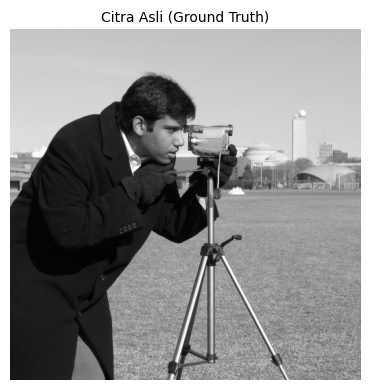

In [ ]:
original = img_as_ubyte(data.camera())
print("Ukuran citra:", original.shape)
show_images([original], ["Citra Asli (Ground Truth)"], figsize=(4, 4))

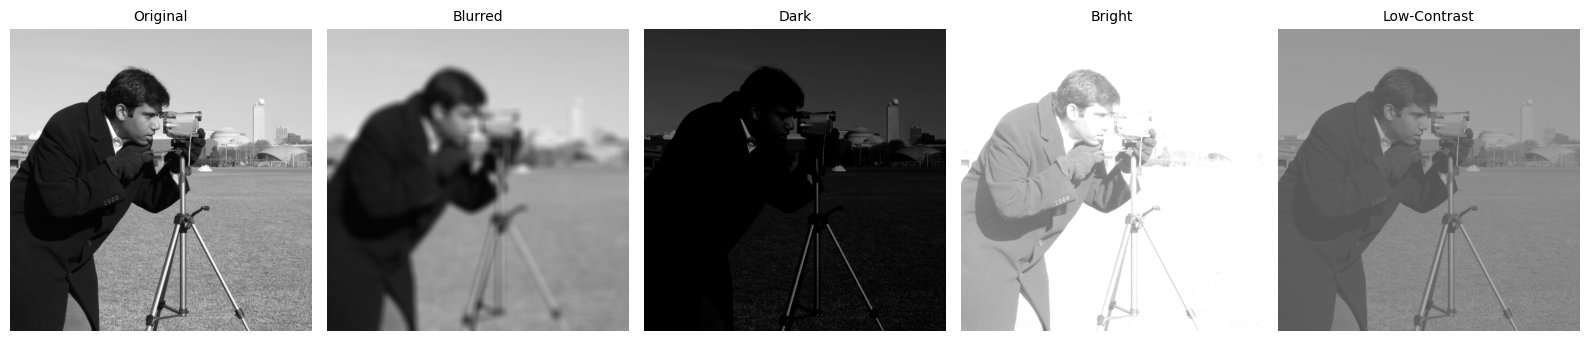

In [4]:
def make_blurred(img, ksize=15, sigma=8):
    """Simulasi citra buram via Gaussian blur."""
    return cv2.GaussianBlur(img, (ksize, ksize), sigma)


def make_dark(img, gamma=3.0, offset=-60):
    """Simulasi citra gelap / underexposed."""
    out = np.clip(img.astype(np.float32) + offset, 0, 255)
    out = 255 * (out / 255) ** gamma
    return np.clip(out, 0, 255).astype(np.uint8)


def make_bright(img, gamma=0.35, offset=60):
    """Simulasi citra terlalu terang / overexposed."""
    out = 255 * (img.astype(np.float32) / 255) ** gamma
    out = np.clip(out + offset, 0, 255)
    return np.clip(out, 0, 255).astype(np.uint8)


def make_low_contrast(img, factor=0.35, mid=128):
    """Simulasi citra kontras rendah (rentang intensitas dipersempit di sekitar nilai tengah)."""
    out = mid + (img.astype(np.float32) - mid) * factor
    return np.clip(out, 0, 255).astype(np.uint8)


degraded = {
    "Blurred": make_blurred(original),
    "Dark": make_dark(original),
    "Bright": make_bright(original),
    "Low-Contrast": make_low_contrast(original),
}

show_images([original] + list(degraded.values()), ["Original"] + list(degraded.keys()),
            figsize=(3.2 * 5, 3.6))

### 3.1 Baseline: MSE & PSNR Sebelum Enhancement

In [5]:
baseline_rows = []
for name, img in degraded.items():
    baseline_rows.append({
        "Jenis Degradasi": name,
        "MSE (sebelum enhancement)": round(calc_mse(original, img), 2),
        "PSNR dB (sebelum enhancement)": round(calc_psnr(original, img), 2),
    })

df_baseline = pd.DataFrame(baseline_rows)
df_baseline

,Jenis Degradasi,MSE (sebelum enhancement),PSNR dB (sebelum enhancement)
0,Blurred,365.74,22.50
1,Dark,15277.11,6.29
2,Bright,11585.78,7.49
3,Low-Contrast,2292.31,14.53


## 4. Pixel-Based Methods (Point Processing)

Metode ini memetakan setiap nilai intensitas pixel $r$ menjadi nilai baru $s$ melalui fungsi
transformasi $T$, **tanpa** melihat pixel tetangga: $s = T(r)$.

### 4.1 Logarithmic Transformation
$$s = c \log(1 + r)$$
Meregangkan (stretch) nilai intensitas **rendah** dan memampatkan (compress) nilai intensitas
**tinggi** — cocok untuk citra dengan rentang dinamis besar atau area gelap yang ingin dimunculkan detailnya.

### 4.2 Power-Law (Gamma) Transformation
$$s = c\, r^{\gamma}$$
$\gamma < 1$ akan **mencerahkan** citra (bagus untuk citra gelap), sedangkan $\gamma > 1$ akan
**menggelapkan** citra (bagus untuk citra terlalu terang). Di notebook ini, $\gamma$ dipilih
**otomatis** per citra (lihat fungsi `auto_gamma`) berdasarkan rata-rata intensitasnya, supaya
adil digunakan untuk setiap jenis degradasi.

### 4.3 Contrast Stretching
Meregangkan rentang intensitas citra secara linear ke rentang penuh $[0, 255]$.

### 4.4 Gray-Level Slicing
Menonjolkan (highlight) rentang intensitas $[r_1, r_2]$ tertentu, sedangkan intensitas di luar
rentang tersebut dipertahankan (*with background*) atau dihilangkan (*without background*):
$$s = \begin{cases} L, & r_1 \le r \le r_2 \\ r \text{ (atau } 0), & \text{lainnya} \end{cases}$$

### 4.5 Histogram Equalization
Meratakan histogram citra secara global agar intensitas tersebar lebih merata di seluruh rentang $[0,255]$.

In [ ]:
def log_transform(img):
    img_f = img.astype(np.float64)
    c = 255.0 / np.log(1 + img_f.max())
    out = c * np.log(1 + img_f)
    return np.clip(out, 0, 255).astype(np.uint8)


def auto_gamma(img, target_mean=0.5):
    mean_norm = np.clip(np.mean(img.astype(np.float64)) / 255.0, 1e-6, 1 - 1e-6)
    return float(np.log(target_mean) / np.log(mean_norm))


def power_law_transform(img, gamma=1.0):
    img_norm = img.astype(np.float64) / 255.0
    out = (img_norm ** gamma) * 255.0
    return np.clip(out, 0, 255).astype(np.uint8)


def contrast_stretching(img):
    img_f = img.astype(np.float64)
    r_min, r_max = img_f.min(), img_f.max()
    if r_max - r_min == 0:
        return img.copy()
    out = (img_f - r_min) * 255.0 / (r_max - r_min)
    return np.clip(out, 0, 255).astype(np.uint8)


def gray_level_slicing(img, low_percentile=40, high_percentile=85,
                        preserve_background=True, highlight_value=255):
    img_f = img.astype(np.float64)
    r1 = np.percentile(img_f, low_percentile)
    r2 = np.percentile(img_f, high_percentile)
    mask = (img_f >= r1) & (img_f <= r2)
    out = img_f.copy() if preserve_background else np.zeros_like(img_f)
    out[mask] = highlight_value
    return np.clip(out, 0, 255).astype(np.uint8)


def histogram_equalization(img):
    return cv2.equalizeHist(img)

## 5. Spatial-Based Methods (Neighborhood Processing / Filtering)

Metode ini menghitung nilai output sebuah pixel berdasarkan pixel tersebut **dan** pixel-pixel
tetangganya (konvolusi kernel, atau statistik pada jendela lokal).

- **Gaussian Filter** — smoothing linear menggunakan kernel Gaussian (meredam noise/detail frekuensi tinggi).
- **Laplacian Filter** — sharpening menggunakan kernel Laplacian (high-pass filter) untuk menguatkan tepi/detail.
- **Median Filter** — smoothing berbasis statistik order (median dari jendela lokal), efektif meredam noise impulsif tanpa terlalu mengaburkan tepi.

In [ ]:
def gaussian_filter(img, ksize=5, sigma=1.0):
    return cv2.GaussianBlur(img, (ksize, ksize), sigma)


def laplacian_filter(img):
    kernel = np.array([[0, -1, 0],
                        [-1, 5, -1],
                        [0, -1, 0]], dtype=np.float32)
    sharpened = cv2.filter2D(img.astype(np.float32), -1, kernel)
    return np.clip(sharpened, 0, 255).astype(np.uint8)


def median_filter(img, ksize=5):
    return cv2.medianBlur(img, ksize)

## 6. Menerapkan SEMUA Metode ke SEMUA Jenis Degradasi

Kedelapan metode (5 pixel-based + 3 spatial-based) diterapkan ke masing-masing dari 4 jenis
citra terdegradasi, sehingga menghasilkan $8 \times 4 = 32$ kombinasi hasil enhancement.

In [8]:
pixel_based_methods = {
    "Log Transform": lambda im: log_transform(im),
    "Power-Law (Gamma) Transform": lambda im: power_law_transform(im, gamma=auto_gamma(im)),
    "Contrast Stretching": lambda im: contrast_stretching(im),
    "Gray-Level Slicing": lambda im: gray_level_slicing(im),
    "Histogram Equalization": lambda im: histogram_equalization(im),
}

spatial_based_methods = {
    "Gaussian Filter": lambda im: gaussian_filter(im, ksize=5, sigma=1.0),
    "Laplacian Filter": lambda im: laplacian_filter(im),
    "Median Filter": lambda im: median_filter(im, ksize=5),
}

all_methods = {}
all_methods.update({f"Pixel-Based - {k}": v for k, v in pixel_based_methods.items()})
all_methods.update({f"Spatial-Based - {k}": v for k, v in spatial_based_methods.items()})

print("Total metode:", len(all_methods))
list(all_methods.keys())

Total metode: 8


['Pixel-Based - Log Transform',
 'Pixel-Based - Power-Law (Gamma) Transform',
 'Pixel-Based - Contrast Stretching',
 'Pixel-Based - Gray-Level Slicing',
 'Pixel-Based - Histogram Equalization',
 'Spatial-Based - Gaussian Filter',
 'Spatial-Based - Laplacian Filter',
 'Spatial-Based - Median Filter']

In [9]:
results = []
enhanced_images = {}

for degrade_type, src_img in degraded.items():
    enhanced_images[degrade_type] = {"Degraded (Sebelum)": src_img}
    for method_name, func in all_methods.items():
        enhanced = func(src_img)
        mse = calc_mse(original, enhanced)
        psnr = calc_psnr(original, enhanced)
        results.append({
            "Jenis Degradasi": degrade_type,
            "Metode": method_name,
            "MSE": round(mse, 2),
            "PSNR (dB)": round(psnr, 2),
        })
        enhanced_images[degrade_type][method_name] = enhanced

df_results = pd.DataFrame(results)
df_results.sort_values(["Jenis Degradasi", "PSNR (dB)"], ascending=[True, False]).reset_index(drop=True)

,Jenis Degradasi,Metode,MSE,PSNR (dB)
0,Blurred,Spatial-Based - Laplacian Filter,365.98,22.50
1,Blurred,Spatial-Based - Median Filter,366.47,22.49
2,Blurred,Spatial-Based - Gaussian Filter,366.97,22.48
3,Blurred,Pixel-Based - Power-Law (Gamma) Transform,368.34,22.47
4,Blurred,Pixel-Based - Contrast Stretching,434.96,21.75
5,Blurred,Pixel-Based - Histogram Equalization,860.85,18.78
6,Blurred,Pixel-Based - Gray-Level Slicing,3960.93,12.15
7,Blurred,Pixel-Based - Log Transform,8491.16,8.84
8,Bright,Pixel-Based - Histogram Equalization,4651.45,11.45
9,Bright,Pixel-Based - Power-Law (Gamma) Transform,4867.94,11.26


## 7. Visualisasi Hasil per Jenis Degradasi


=== Blurred ===


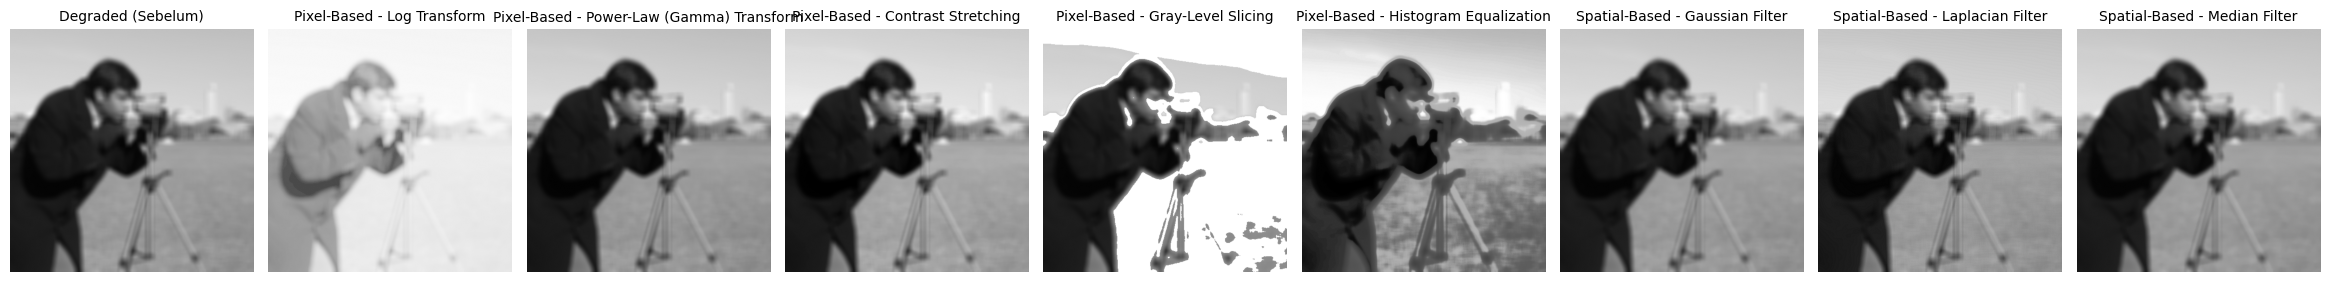


=== Dark ===


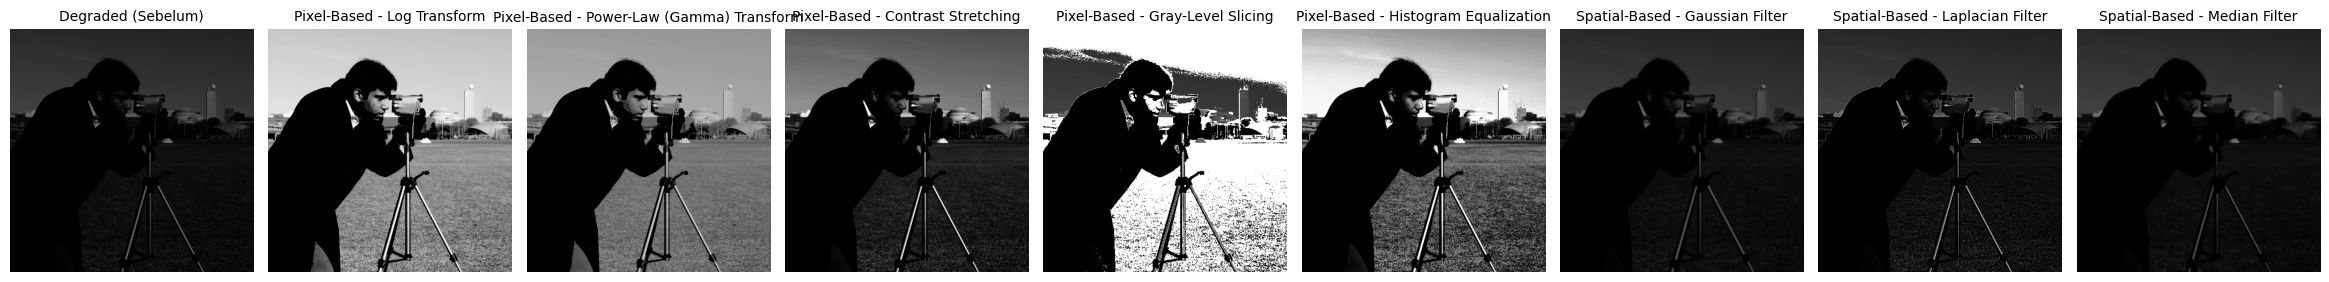


=== Bright ===


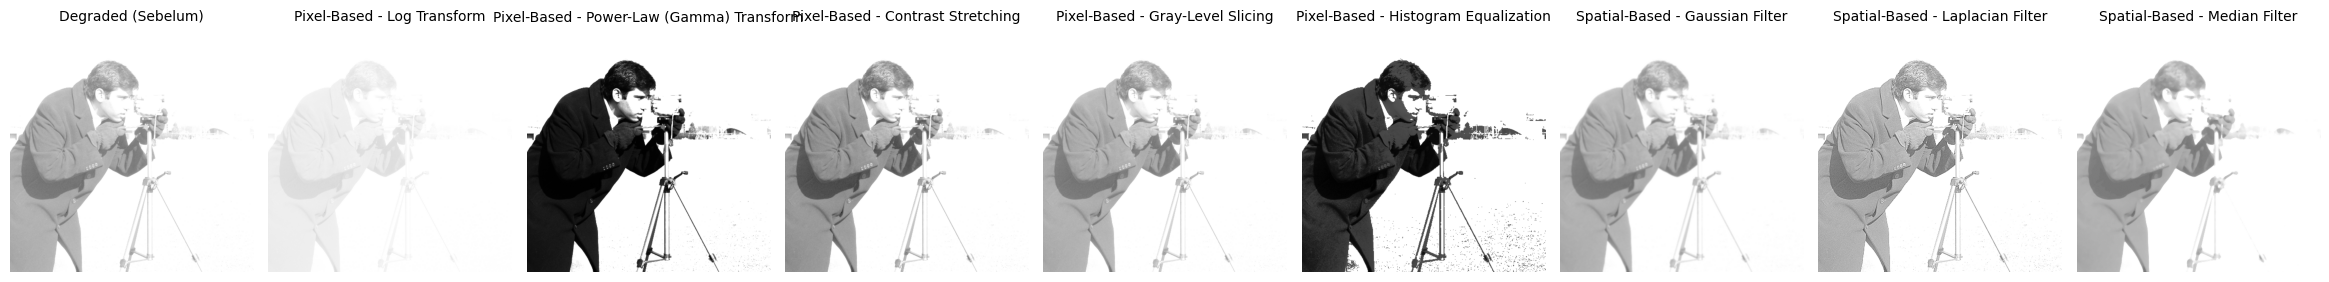


=== Low-Contrast ===


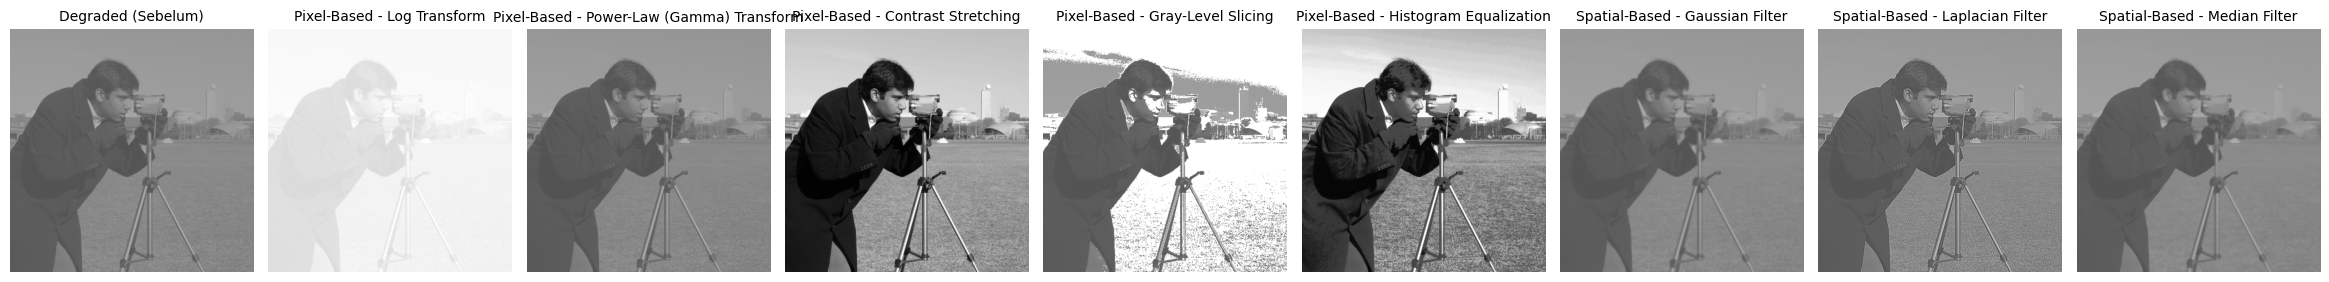

In [10]:
for degrade_type, imgs_dict in enhanced_images.items():
    titles = list(imgs_dict.keys())
    imgs = list(imgs_dict.values())
    print(f"\n=== {degrade_type} ===")
    show_images(imgs, titles, figsize=(2.6 * len(imgs), 3.0))

## 8. Perbandingan MSE & PSNR Antar Metode (Bar Chart per Jenis Degradasi)

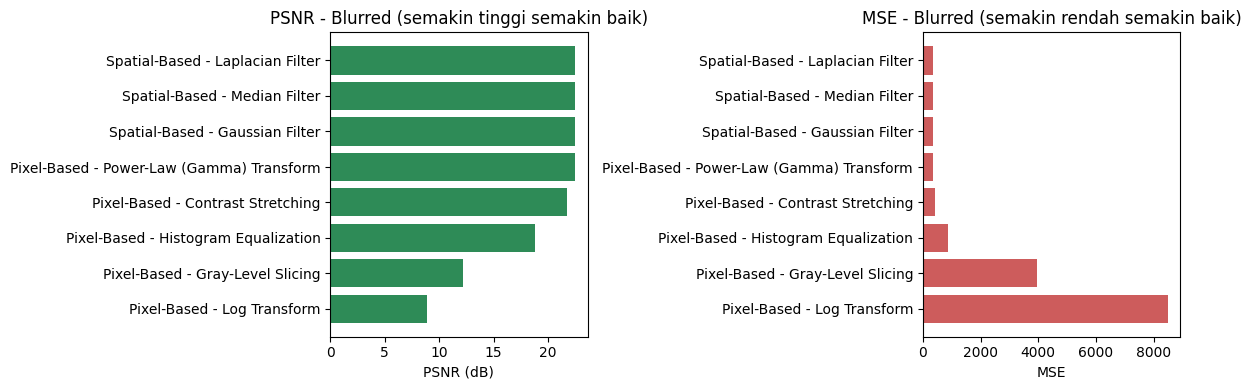

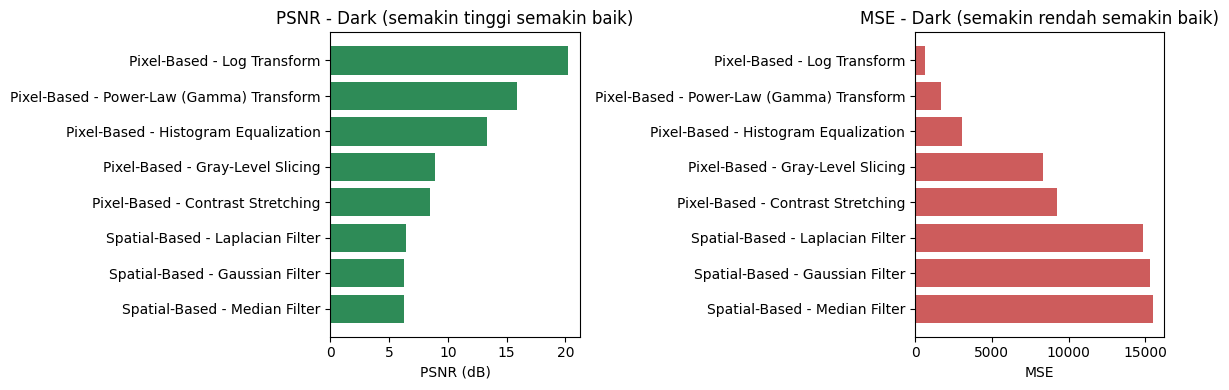

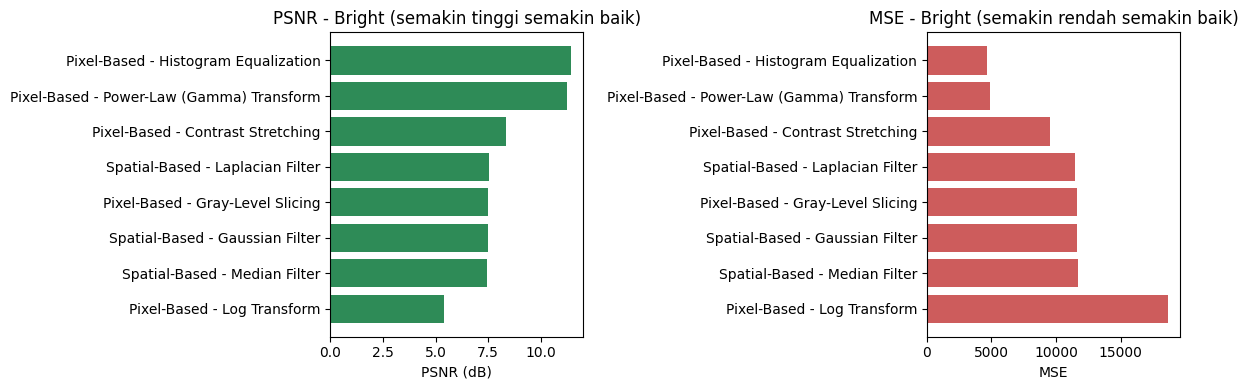

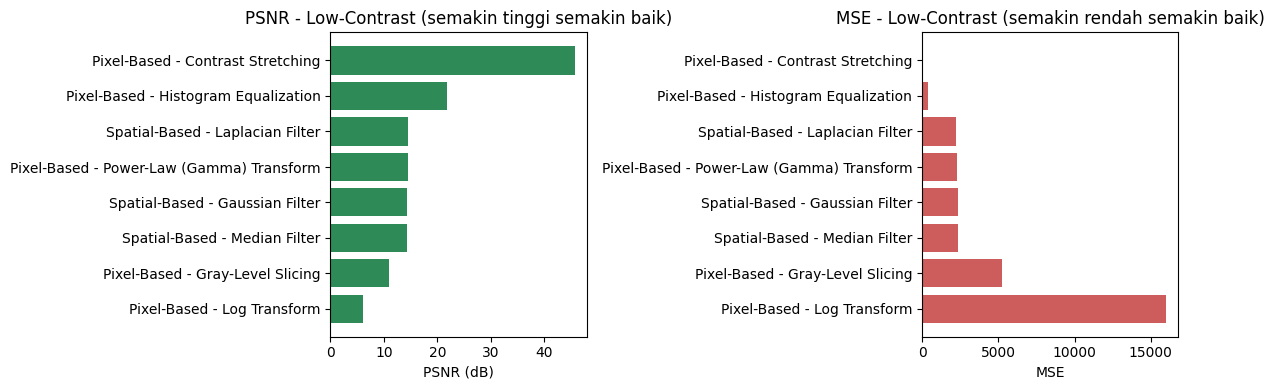

In [11]:
for degrade_type in degraded.keys():
    subset = df_results[df_results["Jenis Degradasi"] == degrade_type].sort_values("PSNR (dB)", ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].barh(subset["Metode"], subset["PSNR (dB)"], color="seagreen")
    axes[0].set_title(f"PSNR - {degrade_type} (semakin tinggi semakin baik)")
    axes[0].set_xlabel("PSNR (dB)")
    axes[0].invert_yaxis()

    axes[1].barh(subset["Metode"], subset["MSE"], color="indianred")
    axes[1].set_title(f"MSE - {degrade_type} (semakin rendah semakin baik)")
    axes[1].set_xlabel("MSE")
    axes[1].invert_yaxis()

    plt.tight_layout()
    plt.show()

## 9. Heatmap Perbandingan Menyeluruh (8 Metode × 4 Jenis Degradasi)

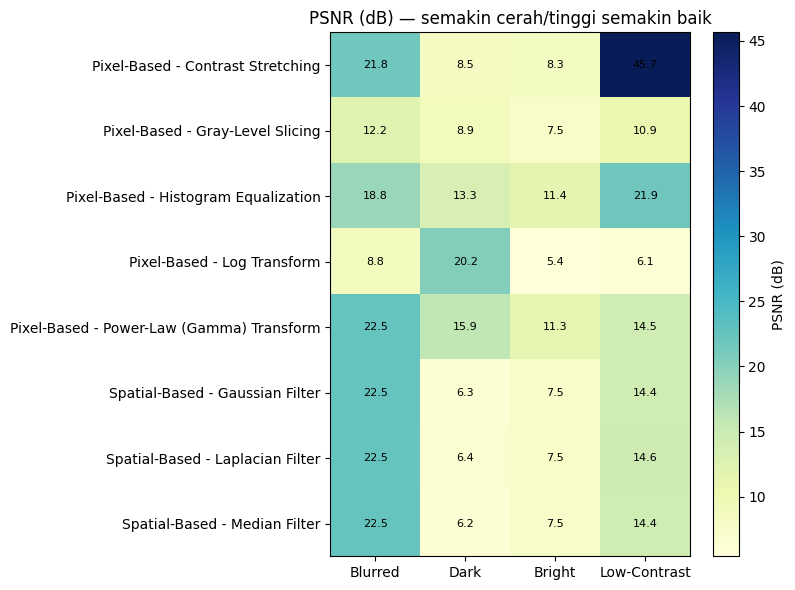

Jenis Degradasi,Blurred,Dark,Bright,Low-Contrast
Metode,,,,
Pixel-Based - Contrast Stretching,21.75,8.48,8.35,45.66
Pixel-Based - Gray-Level Slicing,12.15,8.91,7.49,10.92
Pixel-Based - Histogram Equalization,18.78,13.29,11.45,21.90
Pixel-Based - Log Transform,8.84,20.21,5.42,6.09
Pixel-Based - Power-Law (Gamma) Transform,22.47,15.89,11.26,14.52
Spatial-Based - Gaussian Filter,22.48,6.28,7.48,14.41
Spatial-Based - Laplacian Filter,22.50,6.41,7.55,14.60
Spatial-Based - Median Filter,22.49,6.23,7.45,14.41


In [12]:
pivot_psnr = df_results.pivot(index="Metode", columns="Jenis Degradasi", values="PSNR (dB)")
pivot_psnr = pivot_psnr[list(degraded.keys())]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(pivot_psnr.values, cmap="YlGnBu", aspect="auto")
ax.set_xticks(range(len(pivot_psnr.columns)))
ax.set_xticklabels(pivot_psnr.columns)
ax.set_yticks(range(len(pivot_psnr.index)))
ax.set_yticklabels(pivot_psnr.index)
ax.set_title("PSNR (dB) — semakin cerah/tinggi semakin baik")

for i in range(pivot_psnr.shape[0]):
    for j in range(pivot_psnr.shape[1]):
        ax.text(j, i, f"{pivot_psnr.values[i, j]:.1f}", ha="center", va="center", fontsize=8)

fig.colorbar(im, ax=ax, label="PSNR (dB)")
plt.tight_layout()
plt.show()

pivot_psnr

## 10. Menentukan Metode Enhancement Terbaik

In [13]:
best_methods = df_results.loc[df_results.groupby("Jenis Degradasi")["PSNR (dB)"].idxmax()]
best_methods = best_methods[["Jenis Degradasi", "Metode", "MSE", "PSNR (dB)"]].reset_index(drop=True)
print("Metode enhancement TERBAIK untuk setiap jenis degradasi (berdasarkan PSNR tertinggi / MSE terendah):")
best_methods

Metode enhancement TERBAIK untuk setiap jenis degradasi (berdasarkan PSNR tertinggi / MSE terendah):


,Jenis Degradasi,Metode,MSE,PSNR (dB)
0,Blurred,Spatial-Based - Laplacian Filter,365.98,22.50
1,Bright,Pixel-Based - Histogram Equalization,4651.45,11.45
2,Dark,Pixel-Based - Log Transform,620.16,20.21
3,Low-Contrast,Pixel-Based - Contrast Stretching,1.77,45.66


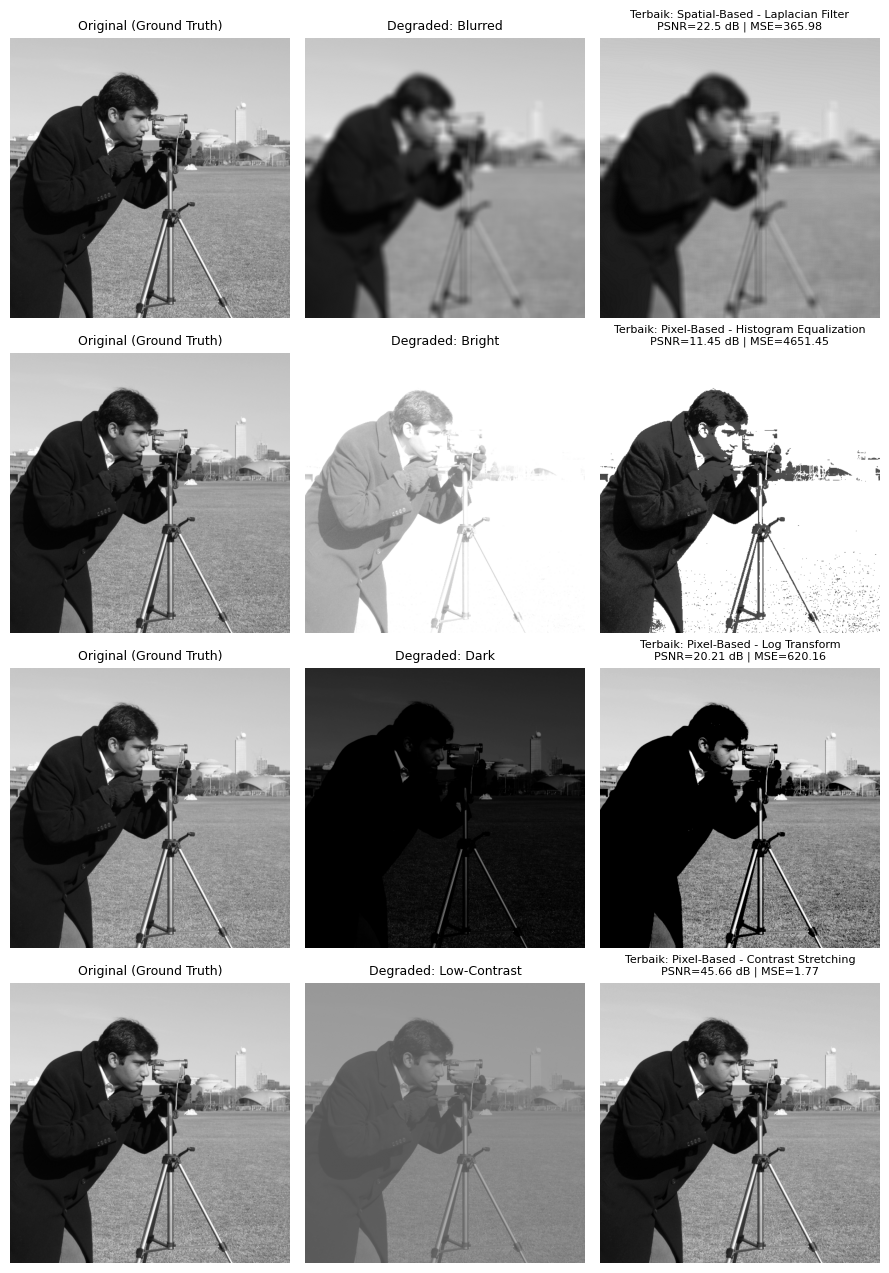

In [14]:
n = len(best_methods)
fig, axes = plt.subplots(n, 3, figsize=(9, 3.2 * n))
for i, row in best_methods.iterrows():
    degrade_type = row["Jenis Degradasi"]
    method_name = row["Metode"]

    axes[i, 0].imshow(original, cmap="gray", vmin=0, vmax=255)
    axes[i, 0].set_title("Original (Ground Truth)", fontsize=9)
    axes[i, 0].axis("off")

    axes[i, 1].imshow(degraded[degrade_type], cmap="gray", vmin=0, vmax=255)
    axes[i, 1].set_title(f"Degraded: {degrade_type}", fontsize=9)
    axes[i, 1].axis("off")

    axes[i, 2].imshow(enhanced_images[degrade_type][method_name], cmap="gray", vmin=0, vmax=255)
    axes[i, 2].set_title(f"Terbaik: {method_name}\nPSNR={row['PSNR (dB)']} dB | MSE={row['MSE']}", fontsize=8)
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

## 11. Kesimpulan

Tabel dan heatmap di atas menunjukkan performa ke-8 metode pada ke-4 jenis degradasi. Pola umum
yang biasanya terlihat pada hasil ini:

- **Blurred** → **Laplacian Filter** (spatial-based, sharpening) biasanya menang karena blur adalah
  masalah *spasial* (informasi menyebar ke pixel tetangga), sehingga hanya bisa dikoreksi dengan
  melihat pixel tetangga. **Gaussian Filter** dan **Median Filter** justru cenderung memperburuk
  citra blur karena keduanya adalah filter *smoothing*, bukan *sharpening*.
- **Dark** → **Power-Law (Gamma) Transform** dengan $\gamma < 1$ dan/atau **Histogram Equalization**
  biasanya paling efektif, karena keduanya secara eksplisit menaikkan intensitas rendah.
  **Log Transform** juga membantu karena meregangkan area gelap.
- **Bright** → **Power-Law (Gamma) Transform** dengan $\gamma > 1$ biasanya paling efektif untuk
  menurunkan intensitas yang terlalu tinggi.
- **Low-Contrast** → **Contrast Stretching** dan **Histogram Equalization** biasanya bersaing ketat
  sebagai yang terbaik, karena keduanya melebarkan rentang dinamis intensitas citra secara langsung.
- **Gray-Level Slicing** umumnya **tidak** menjadi yang terbaik di kategori manapun, karena metode
  ini dirancang untuk *menonjolkan rentang intensitas tertentu* (mis. untuk deteksi objek/fitur),
  bukan untuk memperbaiki kualitas citra secara keseluruhan — sehingga PSNR-nya sering lebih rendah
  dibanding metode lain.

> **Catatan penting:** Parameter (kernel size, sigma, persentil slicing, dst.) dipilih untuk tujuan
> demonstrasi. Untuk citra nyata / dataset lain, sebaiknya parameter di-*tuning* ulang, dan jika ada
> beberapa citra uji, bandingkan **rata-rata MSE/PSNR** dari banyak citra agar kesimpulan metode
> terbaik lebih general (tidak overfit ke satu citra saja).